In [ ]:
# Levi Félix Barbosa - 579420

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

np.random.seed(42)
california = np.genfromtxt('./california.csv', delimiter=',')
indices = np.random.permutation(len(california))

N = len(california)
tam_treino = int(N * 0.8)
tam_teste = N - tam_treino
california_shuffle = california[indices]

X = california_shuffle[:, :-1]
y = california_shuffle[:, -1]

# vamos normalizar X com standard e y com minmax, usando só as estatísticas do conjunto de treino

X_treino_puro = X[:tam_treino, :]
y_treino_puro= y[:tam_treino]

X_teste_puro =  X[tam_treino:, :]
y_teste_puro = y[tam_treino:]

media_x = np.mean(X_treino_puro, axis = 0)
desvio_x = np.sqrt( (np.mean( (X_treino_puro - media_x ) ** 2  * tam_treino / (tam_treino-1), axis=0) ) )

X_treino_norm = (X_treino_puro - media_x) / desvio_x
y_treino_norm = (y_treino_puro - y_treino_puro.min(axis=0)) / (y_treino_puro.max(axis=0) - y_treino_puro.min(axis=0))

# normalizo o x_teste com as mesmas estatísticas do treino
X_teste_norm = (X_teste_puro - media_x) / desvio_x
y_teste_norm = (y_teste_puro - y_treino_puro.min(axis=0)) / (y_treino_puro.max(axis=0) - y_treino_puro.min(axis=0))



array([[-0.34034331,  0.0182833 , -0.74412638, ..., -0.1791833 ,
        -0.87831506,  0.81443156],
       [-0.59720347, -0.99854198,  0.03917895, ..., -0.17717913,
         1.99735401, -1.30781744],
       [-0.75102516,  0.72223927, -1.44362546, ...,  1.00162351,
        -0.77852843,  0.72065777],
       ...,
       [ 2.4099949 ,  0.33115262,  0.5695528 , ..., -0.62886618,
        -0.7921357 ,  0.58740027],
       [ 0.05630217, -0.52923801, -0.21491366, ...,  0.14275246,
         1.14463195, -1.27820466],
       [-0.29287203,  1.81728188, -0.44273998, ..., -0.81033275,
         0.89970115, -1.34730114]], shape=(800, 8))

Ordem: 1 / RMSE do treino: 0.675574 / RMSE do teste: 0.653482 
Ordem: 2 / RMSE do treino: 0.644860 / RMSE do teste: 0.725663 
Ordem: 3 / RMSE do treino: 0.622180 / RMSE do teste: 0.651742 
Ordem: 4 / RMSE do treino: 0.612578 / RMSE do teste: 0.742872 
Ordem: 5 / RMSE do treino: 0.603034 / RMSE do teste: 0.680537 
Ordem: 6 / RMSE do treino: 0.594192 / RMSE do teste: 3.795335 
Ordem: 7 / RMSE do treino: 0.588893 / RMSE do teste: 4.467276 
Ordem: 8 / RMSE do treino: 0.586172 / RMSE do teste: 5.007621 
Ordem: 9 / RMSE do treino: 0.631906 / RMSE do teste: 39.137000 
Ordem: 10 / RMSE do treino: 0.918275 / RMSE do teste: 429.291841 
Ordem: 11 / RMSE do treino: 3.999083 / RMSE do teste: 1992.525454 
Ordem: 12 / RMSE do treino: 86.854555 / RMSE do teste: 115861.365422 
Ordem: 13 / RMSE do treino: 47.665560 / RMSE do teste: 15935.810006 


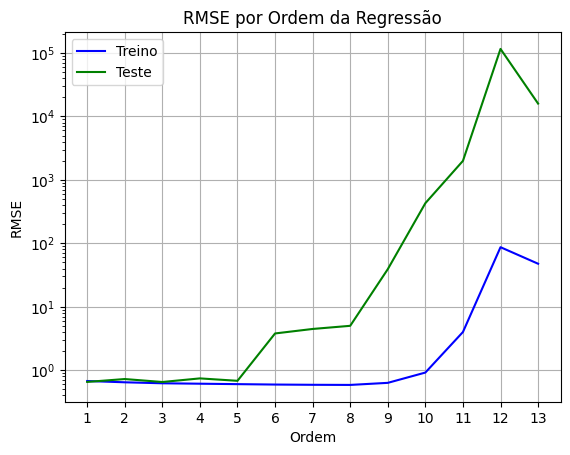

In [30]:
# regressao polinomial pra graus de 1 a 13

rmse_treino_hist = []
rmse_teste_hist = []

for g in range(1, 14):

    # para um grau g
    X_treino = np.ones((tam_treino, 1))
    X_teste = np.ones((tam_teste, 1))
    for i in range(1, g+1):
        X_treino = np.concatenate([X_treino, X_treino_norm**i], axis = 1)
        X_teste = np.concatenate([X_teste, X_teste_norm**i], axis = 1)

    w = np.linalg.inv(X_treino.T @ X_treino) @ X_treino.T @ y_treino_norm

    y_pred_treino = X_treino @ w

    # print("Parâmetros (w):", w)

    y_pred_treino_desnorm = y_pred_treino * (y_treino_puro.max(axis=0) - y_treino_puro.min(axis=0)) + y_treino_puro.min(axis=0)
    rmse_treino = np.sqrt(np.mean((y_pred_treino_desnorm - y_treino_puro) ** 2))
    
    rmse_treino_hist.append(rmse_treino)

    y_pred_teste = X_teste @ w
    y_pred_teste_desnorm = y_pred_teste * (y_treino_puro.max(axis=0) - y_treino_puro.min(axis=0)) + y_treino_puro.min(axis=0)
    rmse_teste = np.sqrt(np.mean((y_pred_teste_desnorm - y_teste_puro) ** 2))
    
    rmse_teste_hist.append(rmse_teste)
    
    print("Ordem: %i / RMSE do treino: %f / RMSE do teste: %f " %(g, rmse_treino, rmse_teste))

plt.plot(range(1, 14), rmse_treino_hist, label = 'Treino', color = 'blue')
plt.plot(range(1, 14), rmse_teste_hist, label = 'Teste', color = 'green')
plt.title("RMSE por Ordem da Regressão")
plt.xlabel("Ordem")
plt.xticks(range(1, 14))
plt.ylabel("RMSE")
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()
    

Ordem: 1 / RMSE do treino: 0.675574 / RMSE do teste: 0.653475 
Ordem: 2 / RMSE do treino: 0.644860 / RMSE do teste: 0.725658 
Ordem: 3 / RMSE do treino: 0.622180 / RMSE do teste: 0.651718 
Ordem: 4 / RMSE do treino: 0.612578 / RMSE do teste: 0.742836 
Ordem: 5 / RMSE do treino: 0.603034 / RMSE do teste: 0.680600 
Ordem: 6 / RMSE do treino: 0.594192 / RMSE do teste: 3.794672 
Ordem: 7 / RMSE do treino: 0.588893 / RMSE do teste: 4.474522 
Ordem: 8 / RMSE do treino: 0.586173 / RMSE do teste: 5.043302 
Ordem: 9 / RMSE do treino: 0.595672 / RMSE do teste: 39.237406 
Ordem: 10 / RMSE do treino: 1.442019 / RMSE do teste: 431.147550 
Ordem: 11 / RMSE do treino: 7.110581 / RMSE do teste: 2033.382376 
Ordem: 12 / RMSE do treino: 294.223947 / RMSE do teste: 106503.039510 
Ordem: 13 / RMSE do treino: 100.589571 / RMSE do teste: 16667.732067 


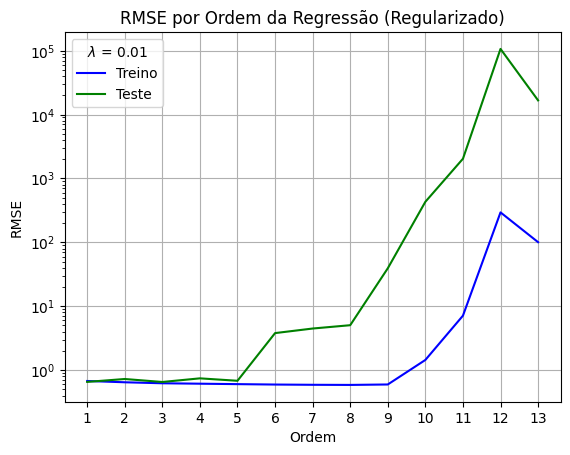

In [42]:
# agora vamos simplesmente adicionar o hiperparâmetro de regularização
# mesmo código, só colocando +reg*identidade no OLS
# fazendo também I(0,0) = 0, para não penalizar o "1" da matriz X. Isto é, a altura da curva não é
# penalizada, apenas seu formato.

reg = 0.01

rmse_treino_hist = []
rmse_teste_hist = []

for g in range(1, 14):

    # para um grau g
    X_treino = np.ones((tam_treino, 1))
    X_teste = np.ones((tam_teste, 1))
    for i in range(1, g+1):
        X_treino = np.concatenate([X_treino, X_treino_norm**i], axis = 1)
        X_teste = np.concatenate([X_teste, X_teste_norm**i], axis = 1)

    I = np.eye(X_treino.shape[1])
    I[0, 0] = 0
    w = np.linalg.inv(X_treino.T @ X_treino + reg*I) @ X_treino.T @ y_treino_norm

    y_pred_treino = X_treino @ w

    # print("Parâmetros (w):", w)

    y_pred_treino_desnorm = y_pred_treino * (y_treino_puro.max(axis=0) - y_treino_puro.min(axis=0)) + y_treino_puro.min(axis=0)
    rmse_treino = np.sqrt(np.mean((y_pred_treino_desnorm - y_treino_puro) ** 2))
    
    rmse_treino_hist.append(rmse_treino)

    y_pred_teste = X_teste @ w
    y_pred_teste_desnorm = y_pred_teste * (y_treino_puro.max(axis=0) - y_treino_puro.min(axis=0)) + y_treino_puro.min(axis=0)
    rmse_teste = np.sqrt(np.mean((y_pred_teste_desnorm - y_teste_puro) ** 2))
    
    rmse_teste_hist.append(rmse_teste)
    
    print("Ordem: %i / RMSE do treino: %f / RMSE do teste: %f " %(g, rmse_treino, rmse_teste))

plt.plot(range(1, 14), rmse_treino_hist, label = 'Treino', color = 'blue')
plt.plot(range(1, 14), rmse_teste_hist, label = 'Teste', color = 'green')
plt.title("RMSE por Ordem da Regressão (Regularizado)")
plt.xlabel("Ordem")
plt.xticks(range(1, 14))
plt.ylabel("RMSE")
plt.yscale('log')
plt.legend()
plt.legend(title=rf"$\lambda$ = {reg}")
plt.grid(True)
plt.show()
    